In [15]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [16]:
cd C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\12.drep\drep_Pvulgatus\04.eggnog

C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\12.drep\drep_Pvulgatus\04.eggnog


In [17]:
# =========================
# Input / output
# =========================
EGGNOG_FILE = 'C02_concoct.31.emapper.annotations'
MAG_NAME = 'C02_concoct.31'

OUT_DIR = "eggnog_python_plots"
os.makedirs(OUT_DIR, exist_ok=True)

sns.set_context("talk")
sns.set_style("white")

In [18]:
def read_emapper_annotations(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"eggNOG annotation file not found: {path}")

    # header line starts with #query
    header = None
    data_lines = []

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if line.startswith("##"):
                continue
            if line.startswith("#query"):
                header = line.strip().lstrip("#").split("\t")
                continue
            if line.startswith("#") or not line.strip():
                continue
            data_lines.append(line.strip().split("\t"))

    if header is None:
        raise ValueError("Could not find #query header line in emapper.annotations")

    df = pd.DataFrame(data_lines, columns=header[:len(data_lines[0])])
    df.columns = [c.strip() for c in df.columns]

    print("eggNOG columns:")
    print(df.columns.tolist())
    print(df.head())

    return df


egg_df = read_emapper_annotations(EGGNOG_FILE)

eggNOG columns:
['query', 'seed_ortholog', 'evalue', 'score', 'eggNOG_OGs', 'max_annot_lvl', 'COG_category', 'Description', 'Preferred_name', 'GOs', 'EC', 'KEGG_ko', 'KEGG_Pathway', 'KEGG_Module', 'KEGG_Reaction', 'KEGG_rclass', 'BRITE', 'KEGG_TC', 'CAZy', 'BiGG_Reaction', 'PFAMs']
          query    seed_ortholog     evalue   score  \
0  IIJEOF_00002  435590.BVU_2435        0.0   863.0   
1  IIJEOF_00003  435590.BVU_2436  3.89e-205   566.0   
2  IIJEOF_00004  435590.BVU_2438        0.0  1429.0   
3  IIJEOF_00005  435590.BVU_2439        0.0   910.0   
4  IIJEOF_00006  435590.BVU_2440        0.0  1125.0   

                                          eggNOG_OGs      max_annot_lvl  \
0  COG2911@1|root,COG2911@2|Bacteria,4NHAF@976|Ba...  976|Bacteroidetes   
1  COG0648@1|root,COG0648@2|Bacteria,4NJDP@976|Ba...  976|Bacteroidetes   
2  2CDRA@1|root,2Z7QN@2|Bacteria,4NHVB@976|Bacter...  976|Bacteroidetes   
3  COG1350@1|root,COG1350@2|Bacteria,4PKSY@976|Ba...  976|Bacteroidetes   
4  COG0168@

In [19]:
COG_MAP = {
    "J": "Translation, ribosomal structure and biogenesis",
    "A": "RNA processing and modification",
    "K": "Transcription",
    "L": "Replication, recombination and repair",
    "B": "Chromatin structure and dynamics",
    "D": "Cell cycle control, cell division, chromosome partitioning",
    "Y": "Nuclear structure",
    "V": "Defense mechanisms",
    "T": "Signal transduction mechanisms",
    "M": "Cell wall/membrane/envelope biogenesis",
    "N": "Cell motility",
    "Z": "Cytoskeleton",
    "W": "Extracellular structures",
    "U": "Intracellular trafficking, secretion, vesicular transport",
    "O": "Post-translational modification, protein turnover, chaperones",
    "X": "Mobilome: prophages, transposons",
    "C": "Energy production and conversion",
    "G": "Carbohydrate transport and metabolism",
    "E": "Amino acid transport and metabolism",
    "F": "Nucleotide transport and metabolism",
    "H": "Coenzyme transport and metabolism",
    "I": "Lipid transport and metabolism",
    "P": "Inorganic ion transport and metabolism",
    "Q": "Secondary metabolites biosynthesis, transport and catabolism",
    "R": "General function prediction only",
    "S": "Function unknown",
}

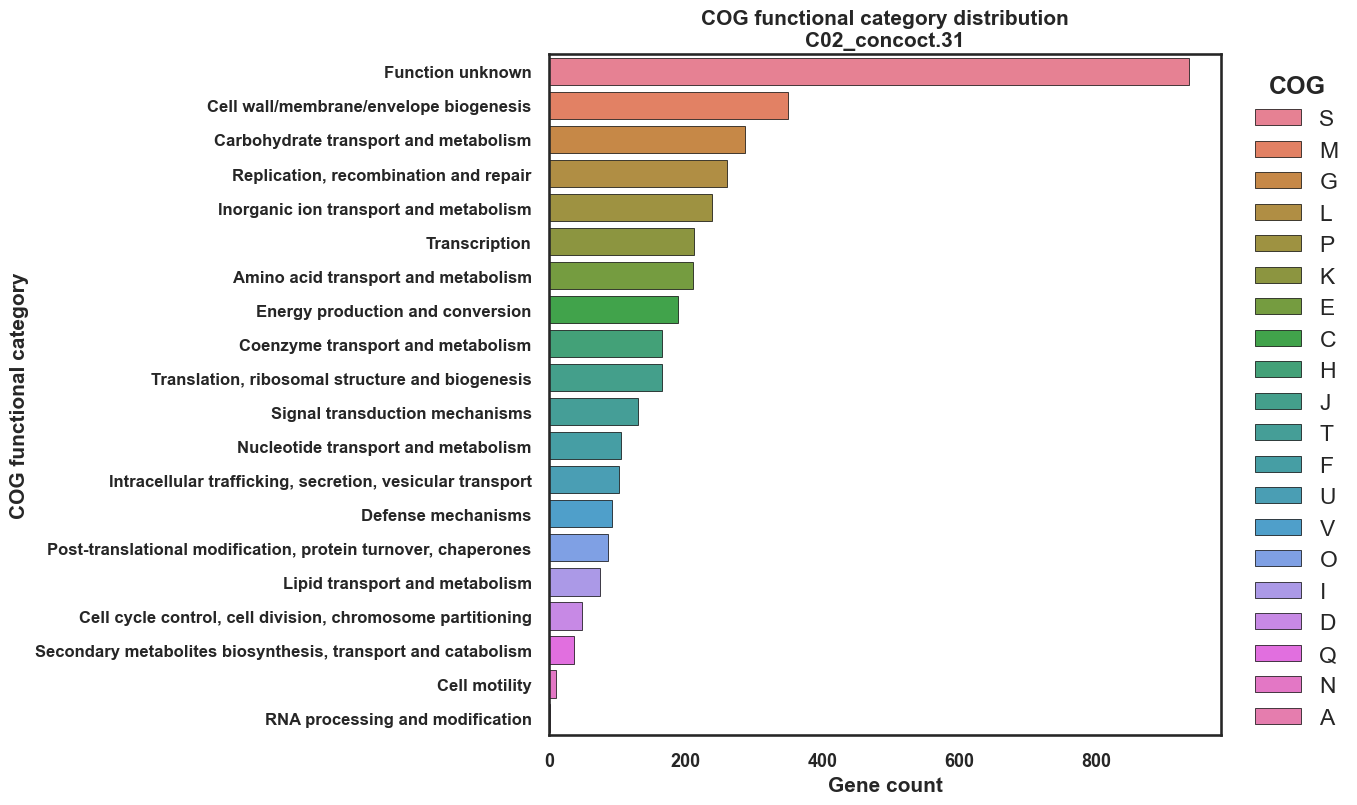

In [20]:
# =========================
# COG category distribution
# =========================
cog_col_candidates = ["COG_category", "COG functional category", "COG_category"]
cog_col = None

for c in cog_col_candidates:
    if c in egg_df.columns:
        cog_col = c
        break

if cog_col is None:
    raise ValueError("No COG category column found.")

cog_rows = []

for val in egg_df[cog_col].fillna("-"):
    val = str(val).strip()
    if val in ["", "-", "nan", "NaN"]:
        continue

    # Some genes can have multiple COG letters, e.g. "EG" or "S"
    for letter in list(val):
        if letter in COG_MAP:
            cog_rows.append({
                "COG": letter,
                "COG_category": COG_MAP[letter]
            })

cog_counts = (
    pd.DataFrame(cog_rows)
    .value_counts(["COG", "COG_category"])
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

plt.figure(figsize=(14, max(5, len(cog_counts) * 0.42)))

ax = sns.barplot(
    data=cog_counts,
    y="COG_category",
    x="Count",
    hue="COG",
    dodge=False,
    edgecolor="black",
    linewidth=0.5
)

plt.xlabel("Gene count", fontsize=15, fontweight="bold")
plt.ylabel("COG functional category", fontsize=15, fontweight="bold")
plt.title(f"COG functional category distribution\n{MAG_NAME}", fontsize=15, fontweight="bold")

plt.xticks(fontsize=13, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

leg = ax.legend(title="COG", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
leg.get_title().set_fontweight("bold")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "COG_category_distribution.png"), dpi=500, bbox_inches="tight")
plt.show()

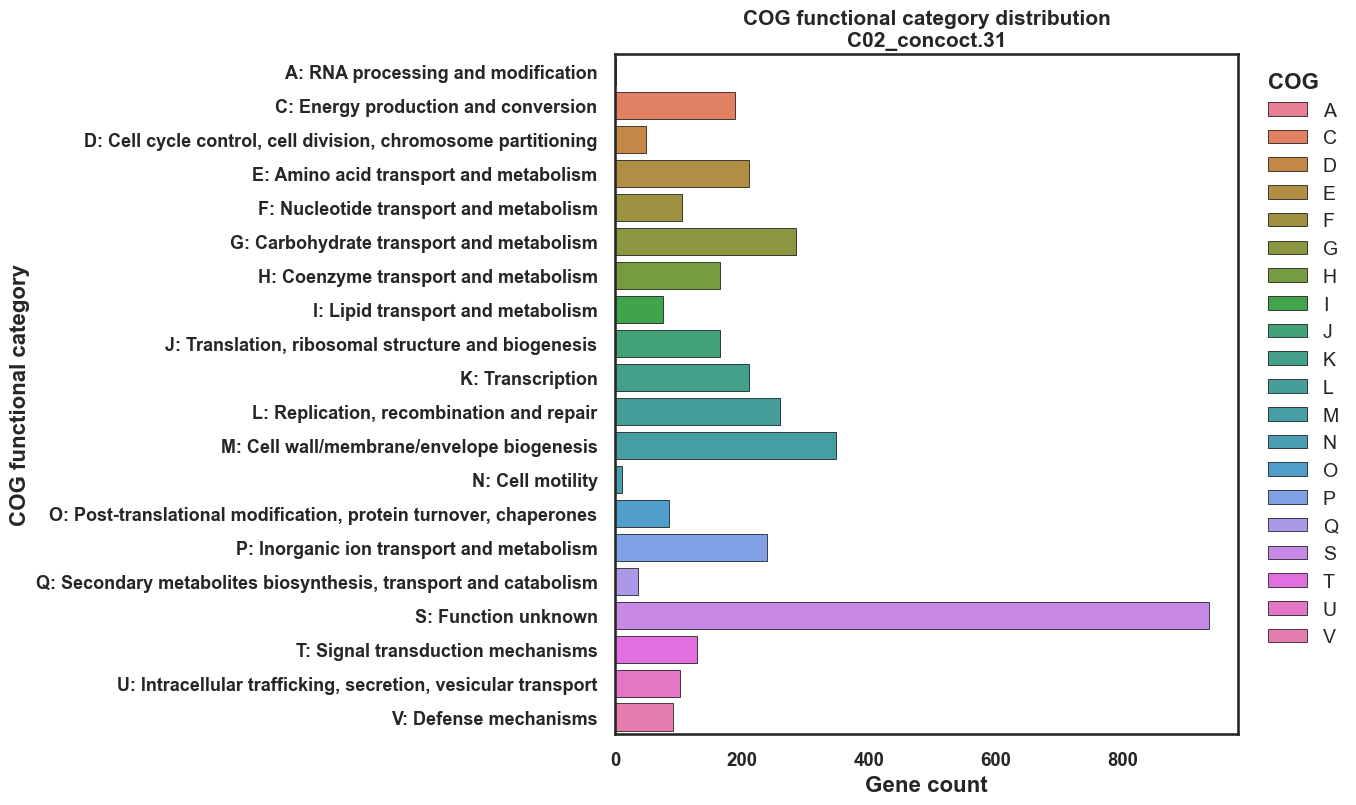

In [21]:
# =========================
# COG category distribution
# =========================
cog_col_candidates = ["COG_category", "COG functional category", "COG_category"]
cog_col = None

for c in cog_col_candidates:
    if c in egg_df.columns:
        cog_col = c
        break

if cog_col is None:
    raise ValueError("No COG category column found.")

cog_rows = []

for val in egg_df[cog_col].fillna("-"):
    val = str(val).strip()
    if val in ["", "-", "nan", "NaN"]:
        continue

    # Some genes can have multiple COG letters, e.g. "EG" or "S"
    for letter in list(val):
        if letter in COG_MAP:
            cog_rows.append({
                "COG": letter,
                "COG_category": COG_MAP[letter]
            })

# =========================
# COG count table: A-Z order
# =========================
cog_counts = (
    pd.DataFrame(cog_rows)
    .value_counts(["COG", "COG_category"])
    .reset_index(name="Count")
)

# COG 알파벳 순서
cog_order = sorted(cog_counts["COG"].unique())

# y축 label에 COG letter를 같이 표시할지 여부
SHOW_COG_LETTER_IN_YLABEL = True

if SHOW_COG_LETTER_IN_YLABEL:
    cog_counts["COG_label"] = cog_counts["COG"] + ": " + cog_counts["COG_category"]
    y_col = "COG_label"
else:
    y_col = "COG_category"

# A-Z 순서로 정렬
cog_counts["COG"] = pd.Categorical(cog_counts["COG"], categories=cog_order, ordered=True)
cog_counts = cog_counts.sort_values("COG")

# y축 순서도 A-Z 기준
y_order = cog_counts[y_col].tolist()

# =========================
# Plot
# =========================
plt.figure(figsize=(14, max(5, len(cog_counts) * 0.42)))

ax = sns.barplot(
    data=cog_counts,
    y=y_col,
    x="Count",
    hue="COG",
    order=y_order,
    hue_order=cog_order,
    dodge=False,
    edgecolor="black",
    linewidth=0.5
)

plt.xlabel("Gene count", fontsize=16, fontweight="bold")
plt.ylabel("COG functional category", fontsize=16, fontweight="bold")
plt.title(f"COG functional category distribution\n{MAG_NAME}", fontsize=15, fontweight="bold")

plt.xticks(fontsize=13.5, fontweight="bold")
plt.yticks(fontsize=13, fontweight="bold")

# =========================
# Legend formatting
# =========================
leg = ax.legend(
    title="COG",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=14,
    title_fontsize=16
)

# legend title 좌측 정렬 + bold
leg._legend_box.align = "left"
leg.get_title().set_fontweight("bold")
leg.get_title().set_ha("left")

# legend item 좌측 정렬
for txt in leg.get_texts():
    txt.set_ha("left")
    txt.set_fontsize(14)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "COG_category_distribution_AZ_order.png"), dpi=500, bbox_inches="tight")
plt.show()

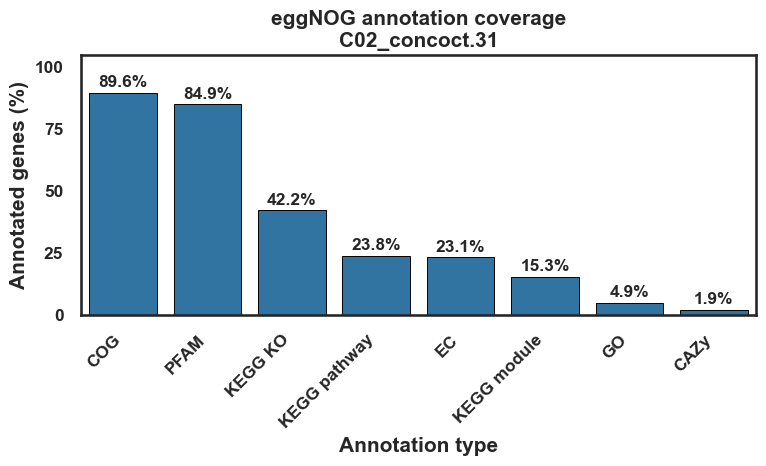

In [22]:
# =========================
# Annotation coverage summary
# =========================
def has_valid_annotation(x):
    if pd.isna(x):
        return False
    x = str(x).strip()
    return x not in ["", "-", "nan", "NaN", "None"]

annotation_cols = {
    "COG": cog_col,
    "GO": "GOs",
    "EC": "EC",
    "KEGG KO": "KEGG_ko",
    "KEGG pathway": "KEGG_Pathway",
    "KEGG module": "KEGG_Module",
    "PFAM": "PFAMs",
    "CAZy": "CAZy",
}

coverage_rows = []

for label, col in annotation_cols.items():
    if col in egg_df.columns:
        n_annot = egg_df[col].apply(has_valid_annotation).sum()
        n_total = egg_df.shape[0]
        coverage_rows.append({
            "Annotation_type": label,
            "Annotated_genes": n_annot,
            "Percent": n_annot / n_total * 100
        })

coverage_df = pd.DataFrame(coverage_rows).sort_values("Annotated_genes", ascending=False)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=coverage_df,
    x="Annotation_type",
    y="Percent",
    edgecolor="black",
    linewidth=0.7
)

for p, pct in zip(ax.patches, coverage_df["Percent"]):
    h = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        h + 1,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12.5,
        fontweight="bold"
    )

plt.xlabel("Annotation type", fontsize=15, fontweight="bold")
plt.ylabel("Annotated genes (%)", fontsize=15, fontweight="bold")
plt.title(f"eggNOG annotation coverage\n{MAG_NAME}", fontsize=15, fontweight="bold")

plt.xticks(fontsize=12.5, fontweight='bold', ha='right', rotation=45)
plt.yticks(fontsize=12.5, fontweight='bold')
plt.ylim(0, min(105, max(coverage_df["Percent"]) + 15))

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "annotation_coverage.png"), dpi=500, bbox_inches="tight")
plt.show()

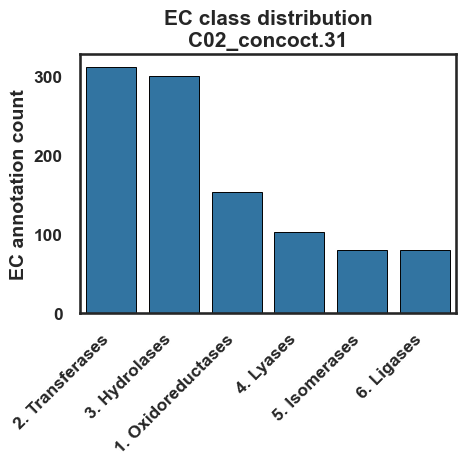

In [45]:
# =========================
# EC class distribution
# =========================
if "EC" in egg_df.columns:
    ec_rows = []

    for val in egg_df["EC"].fillna("-"):
        val = str(val).strip()
        if val in ["", "-", "nan", "NaN"]:
            continue

        ecs = re.split(r",|\|", val)
        for ec in ecs:
            ec = ec.strip()
            if re.match(r"^\d+\.", ec):
                ec_class = ec.split(".")[0]
                ec_rows.append({
                    "EC": ec,
                    "EC_class": ec_class
                })

    ec_df = pd.DataFrame(ec_rows)

    if not ec_df.empty:
        EC_CLASS_MAP = {
            "1": "Oxidoreductases",
            "2": "Transferases",
            "3": "Hydrolases",
            "4": "Lyases",
            "5": "Isomerases",
            "6": "Ligases",
            "7": "Translocases",
        }

        ec_counts = (
            ec_df["EC_class"]
            .value_counts()
            .rename_axis("EC_class")
            .reset_index(name="Count")
        )

        ec_counts["EC_class_name"] = ec_counts["EC_class"].map(EC_CLASS_MAP).fillna(ec_counts["EC_class"])
        ec_counts["Label"] = ec_counts["EC_class"] + ". " + ec_counts["EC_class_name"]

        plt.figure(figsize=(5, 5))

        ax = sns.barplot(
            data=ec_counts,
            x="Label",
            y="Count",
            edgecolor="black",
            linewidth=0.7
        )

        plt.xlabel("", fontsize=14, fontweight="bold")
        plt.ylabel("EC annotation count", fontsize=14, fontweight="bold")
        plt.title(f"EC class distribution\n{MAG_NAME}", fontsize=15, fontweight="bold")

        plt.xticks(fontsize=12.5, fontweight='bold', ha='right', rotation=45)
        plt.yticks(fontsize=12.5, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, "EC_class_distribution_level1.png"), dpi=500, bbox_inches="tight")
        plt.show()

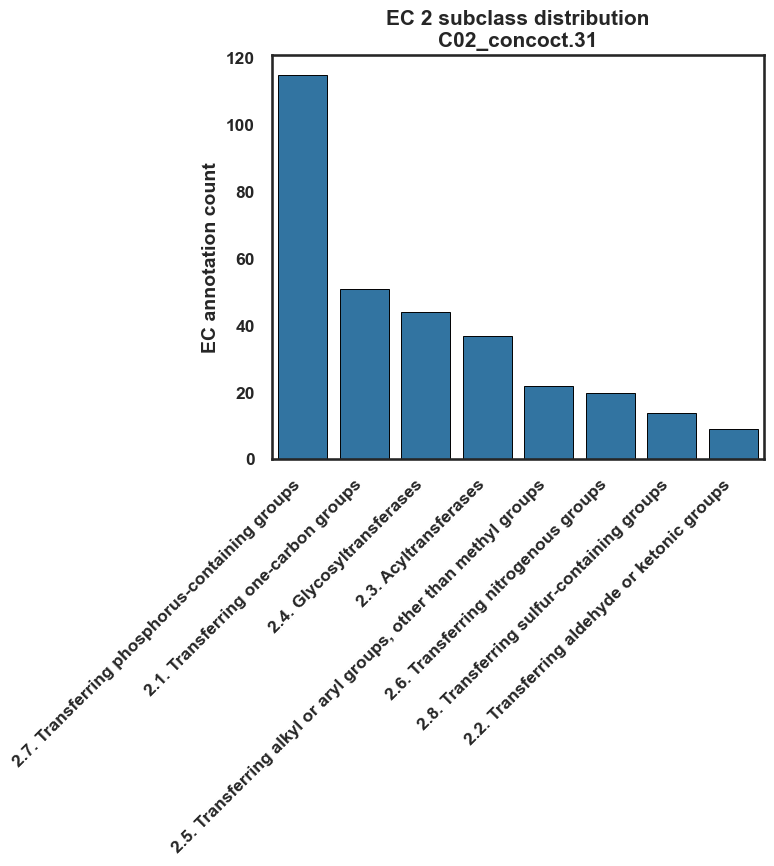

In [60]:
# =========================
# EC subclass distribution: 2.1, 2.2, 2.3 ...
# =========================
if "EC" in egg_df.columns:
    ec_rows = []

    for val in egg_df["EC"].fillna("-"):
        val = str(val).strip()
        if val in ["", "-", "nan", "NaN"]:
            continue

        ecs = re.split(r",|\|", val)
        for ec in ecs:
            ec = ec.strip()
            if re.match(r"^\d+\.\d+\.", ec):
                # 2.x.x.x 만 선택
                if ec.startswith("2."):
                    ec_class = ".".join(ec.split(".")[:2])
                    ec_rows.append({
                        "EC": ec,
                        "EC_class": ec_class
                        })

    ec_df = pd.DataFrame(ec_rows)

    if not ec_df.empty:
        EC_CLASS_MAP = {
            "2.1": "Transferring one-carbon groups",
            "2.2": "Transferring aldehyde or ketonic groups",
            "2.3": "Acyltransferases",
            "2.4": "Glycosyltransferases",
            "2.5": "Transferring alkyl or aryl groups, other than methyl groups",
            "2.6": "Transferring nitrogenous groups",
            "2.7": "Transferring phosphorus-containing groups",
            "2.8": "Transferring sulfur-containing groups",
            "2.9": "Transferring selenium-containing groups",
            "2.10": "Transferring molybdenum- or tungsten-containing groups"
        }

        ec_counts = (
            ec_df["EC_class"]
            .value_counts()
            .rename_axis("EC_class")
            .reset_index(name="Count")
        )

        ec_counts["EC_class_name"] = ec_counts["EC_class"].map(EC_CLASS_MAP).fillna(ec_counts["EC_class"])
        ec_counts["Label"] = ec_counts["EC_class"] + ". " + ec_counts["EC_class_name"]

        plt.figure(figsize=(8, 9))

        ax = sns.barplot(
            data=ec_counts,
            x="Label",
            y="Count",
            edgecolor="black",
            linewidth=0.7
        )

        plt.xlabel("", fontsize=14, fontweight="bold")
        plt.ylabel("EC annotation count", fontsize=14, fontweight="bold")
        plt.title(f"EC 2 subclass distribution\n{MAG_NAME}", fontsize=15, fontweight="bold")

        plt.xticks(fontsize=12.5, fontweight='bold', ha='right', rotation=45)
        plt.yticks(fontsize=12.5, fontweight='bold')

        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, "EC_class_distribution_level2.png"), dpi=500, bbox_inches="tight")
        plt.show()

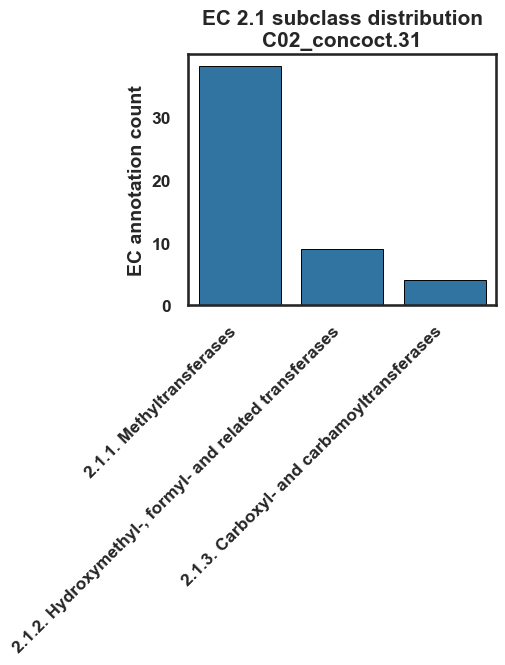

In [68]:
# =========================
# EC sub-subclass distribution: 2.1.1, 2.1.2, 2.1.3 ...
# =========================
if "EC" in egg_df.columns:
    ec_rows = []

    for val in egg_df["EC"].fillna("-"):
        val = str(val).strip()
        if val in ["", "-", "nan", "NaN"]:
            continue

        ecs = re.split(r",|\|", val)
        for ec in ecs:
            ec = ec.strip()
            if re.match(r"^\d+\.\d+\.\d+\.", ec):
                # 2.1.x.x 만 선택
                if ec.startswith("2.1."):
                    ec_class = ".".join(ec.split(".")[:3])
                    ec_rows.append({
                        "EC": ec,
                        "EC_class": ec_class
                        })

    ec_df = pd.DataFrame(ec_rows)

    if not ec_df.empty:
        EC_CLASS_MAP = {
            "2.1.1": "Methyltransferases",
            "2.1.2": "Hydroxymethyl-, formyl- and related transferases",
            "2.1.3": "Carboxyl- and carbamoyltransferases",
            "2.1.4": "Amidinotransferases",
            "2.1.5": "Methylenetransferases",
            "2.1.6": "Related transferases",
            "2.1.7": "Alkyl or aryl transferases",
            "2.1.8": "Sulfur-group transferases"
        }

        ec_counts = (
            ec_df["EC_class"]
            .value_counts()
            .rename_axis("EC_class")
            .reset_index(name="Count")
        )

        ec_counts["EC_class_name"] = ec_counts["EC_class"].map(EC_CLASS_MAP).fillna(ec_counts["EC_class"])
        ec_counts["Label"] = ec_counts["EC_class"] + ". " + ec_counts["EC_class_name"]

        plt.figure(figsize=(5, 7))

        ax = sns.barplot(
            data=ec_counts,
            x="Label",
            y="Count",
            edgecolor="black",
            linewidth=0.7
        )

        plt.xlabel("", fontsize=14, fontweight="bold")
        plt.ylabel("EC annotation count", fontsize=14, fontweight="bold")
        plt.title(f"EC 2.1 subclass distribution\n{MAG_NAME}", fontsize=15, fontweight="bold")

        plt.xticks(fontsize=12.5, fontweight='bold', ha="right", rotation=45)
        plt.yticks(fontsize=12.5, fontweight='bold')

        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, "EC_class_distribution_level3.png"), dpi=500, bbox_inches="tight")
        plt.show()

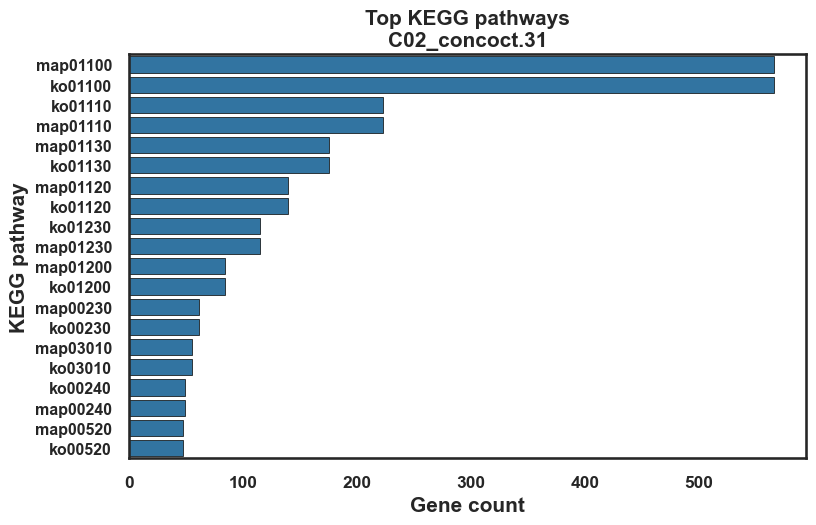

In [43]:
# =========================
# Top KEGG pathways
# =========================
path_col = "KEGG_Pathway"

if path_col in egg_df.columns:
    pathway_rows = []

    for val in egg_df[path_col].fillna("-"):
        val = str(val).strip()
        if val in ["", "-", "nan", "NaN"]:
            continue

        paths = re.split(r",|\|", val)
        for p in paths:
            p = p.strip()
            if p and p not in ["-", "nan"]:
                pathway_rows.append(p)

    pathway_counts = (
        pd.Series(pathway_rows)
        .value_counts()
        .reset_index()
    )
    pathway_counts.columns = ["KEGG_pathway", "Count"]

    TOP_N = 20
    pathway_top = pathway_counts.head(TOP_N)

    if not pathway_top.empty:
        plt.figure(figsize=(8.5, max(5, TOP_N * 0.28)))

        ax = sns.barplot(
            data=pathway_top,
            y="KEGG_pathway",
            x="Count",
            edgecolor="black",
            linewidth=0.5
        )

        plt.xlabel("Gene count", fontsize=15, fontweight="bold")
        plt.ylabel("KEGG pathway", fontsize=15, fontweight="bold")
        plt.title(f"Top KEGG pathways\n{MAG_NAME}", fontsize=15, fontweight="bold")

        plt.xticks(fontsize=12.5, fontweight='bold')
        plt.yticks(fontsize=11.5, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(os.path.join(OUT_DIR, "_top_KEGG_pathways.png"), dpi=500, bbox_inches="tight")
        plt.show()

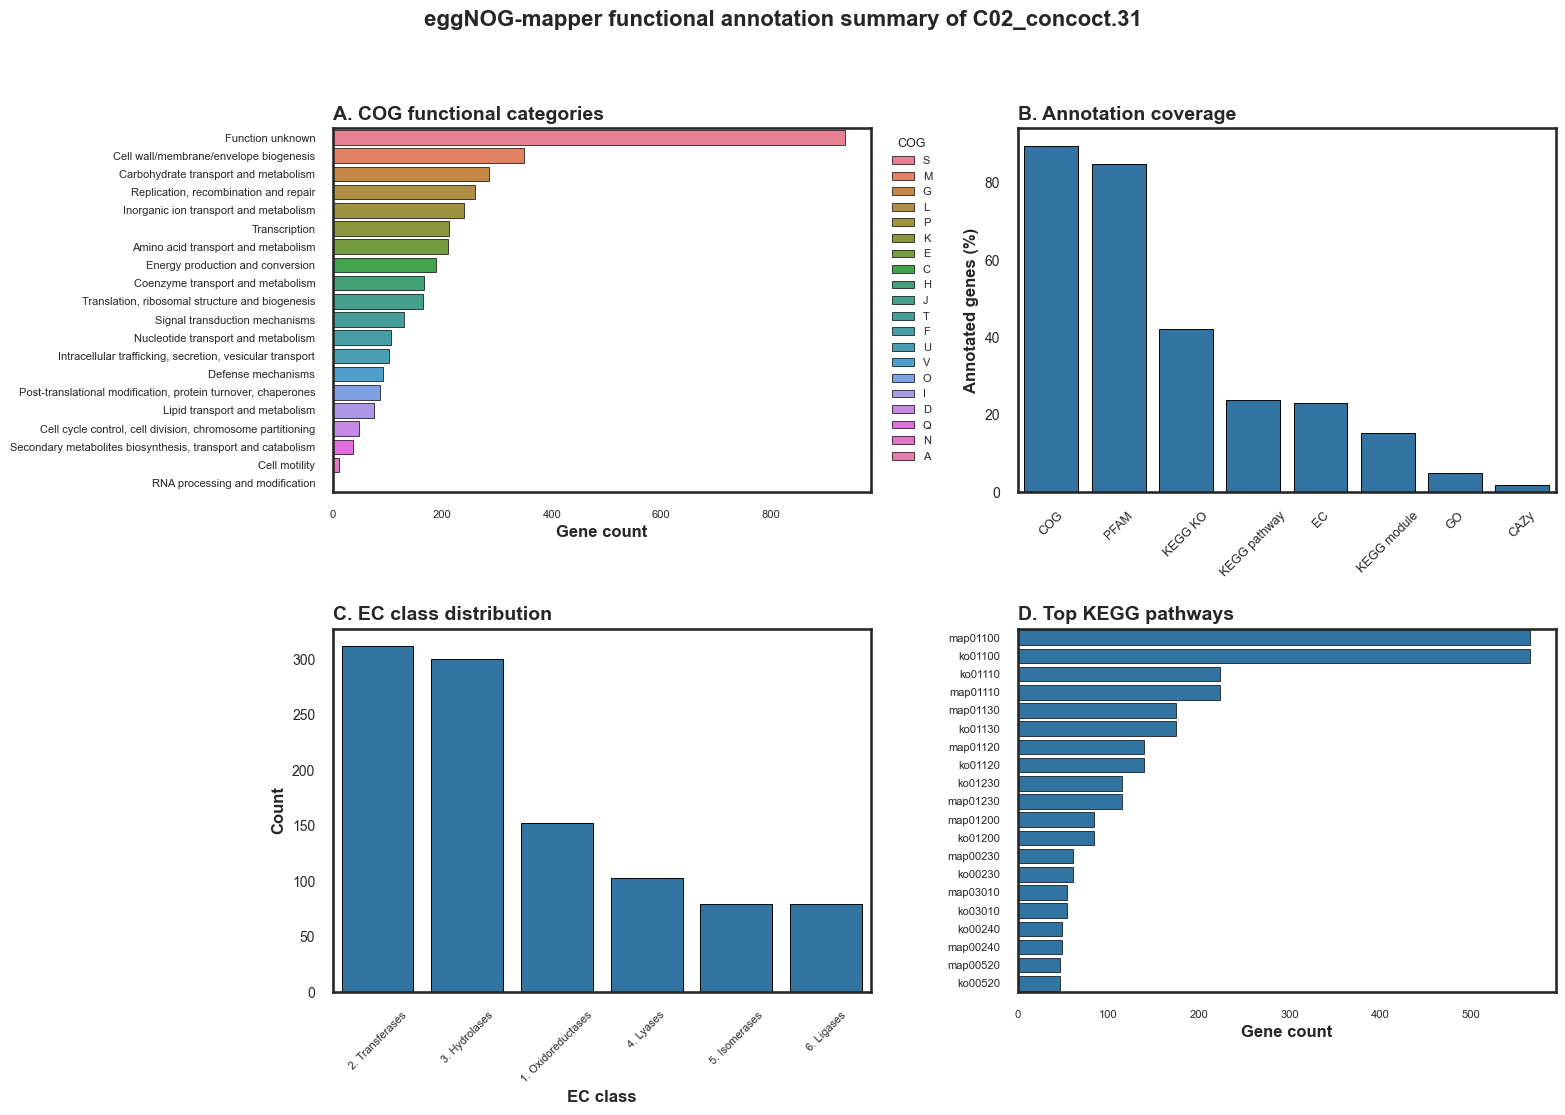

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# A. COG
ax = axes[0, 0]
sns.barplot(data=cog_counts, y="COG_category", x="Count", hue="COG", dodge=False,
            edgecolor="black", linewidth=0.5, ax=ax)
ax.set_title("A. COG functional categories", fontsize=14, fontweight="bold", loc="left")
ax.set_xlabel("Gene count", fontsize=12, fontweight="bold")
ax.set_ylabel("")
ax.tick_params(axis="both", labelsize=8)
ax.legend(title="COG", frameon=False, fontsize=8, title_fontsize=9, bbox_to_anchor=(1.02, 1), loc="upper left")

# B. Coverage
ax = axes[0, 1]
sns.barplot(data=coverage_df, x="Annotation_type", y="Percent",
            edgecolor="black", linewidth=0.7, ax=ax)
ax.set_title("B. Annotation coverage", fontsize=14, fontweight="bold", loc="left")
ax.set_xlabel("")
ax.set_ylabel("Annotated genes (%)", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", labelsize=10)

# C. EC
ax = axes[1, 0]
if "ec_counts" in globals() and not ec_counts.empty:
    sns.barplot(data=ec_counts, x="Label", y="Count", edgecolor="black", linewidth=0.7, ax=ax)
    ax.set_title("C. EC class distribution", fontsize=14, fontweight="bold", loc="left")
    ax.set_xlabel("EC class", fontsize=12, fontweight="bold")
    ax.set_ylabel("Count", fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", labelsize=10)
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "No EC annotations", ha="center", va="center")

# D. KEGG pathway
ax = axes[1, 1]
if "pathway_top" in globals() and not pathway_top.empty:
    sns.barplot(data=pathway_top, y="KEGG_pathway", x="Count", edgecolor="black", linewidth=0.5, ax=ax)
    ax.set_title("D. Top KEGG pathways", fontsize=14, fontweight="bold", loc="left")
    ax.set_xlabel("Gene count", fontsize=12, fontweight="bold")
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=8)
else:
    ax.axis("off")
    ax.text(0.5, 0.5, "No KEGG pathway annotations", ha="center", va="center")

plt.suptitle(f"eggNOG-mapper functional annotation summary of {MAG_NAME}",
             fontsize=16, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "eggNOG_combined_panel.png"), dpi=500, bbox_inches="tight")
plt.show()